In [1]:
import pandas as pd
from evaluate import load

C:\Users\27355\Desktop\New folder\Data Science\Automated-Abstractive-Text-Summarization\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_df = pd.read_csv("data/bart_generated_summaries.csv")

results_df.head()

,Article,Human Summary,BART Summary
0,They recorded their best result in Wales in 30...,The general election dominated politics in Wal...,Labour recorded their best result in Wales in ...
1,"More than 1,500 children were held over allege...",Children as young as 10 were among hundreds of...,"More than 1,500 children were held over allege..."
2,"It includes:\nCertainly, Sinn Féin leader Gerr...",A bewildering list of developments has contrib...,Sinn Féin leader Gerry Adams thinks there has ...
3,"Then a young man in his mid-20s, the future mu...","In March 1959, as Chinese troops crushed an at...","The 14th Dalai Lama was born on 6 July 1935, i..."
4,"Almost 2,000 homes and more than 1,000 busines...",A £3m fund to invest in flood prevention and r...,"Almost 2,000 homes and businesses in the Calde..."


In [3]:
rouge = load("rouge")

print("✅ ROUGE metric loaded successfully!")

✅ ROUGE metric loaded successfully!


In [4]:
scores = rouge.compute(
    predictions=results_df["BART Summary"],
    references=results_df["Human Summary"]
)

print(scores)

{'rouge1': np.float64(0.1910261304928298), 'rouge2': np.float64(0.022736418511066402), 'rougeL': np.float64(0.13364144269355122), 'rougeLsum': np.float64(0.1337257383677282)}


In [5]:
print("=" * 40)
print("BART Model Evaluation")
print("=" * 40)

print(f"ROUGE-1 : {scores['rouge1']:.4f}")
print(f"ROUGE-2 : {scores['rouge2']:.4f}")
print(f"ROUGE-L : {scores['rougeL']:.4f}")

BART Model Evaluation
ROUGE-1 : 0.1910
ROUGE-2 : 0.0227
ROUGE-L : 0.1336


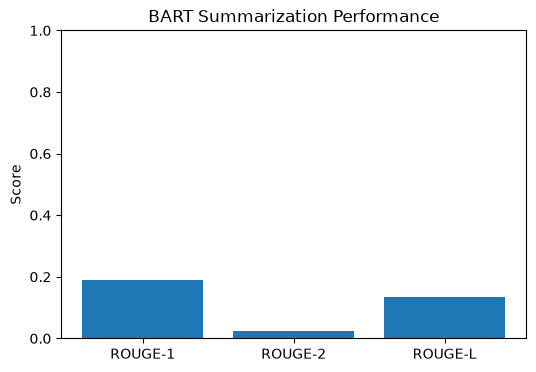

In [6]:
import matplotlib.pyplot as plt

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
values = [
    scores["rouge1"],
    scores["rouge2"],
    scores["rougeL"]
]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values)

plt.title("BART Summarization Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()